# 🏪 Superstore — Phase 2: Complete EDA
### Wizalyze 2026 | NMIT Bengaluru | Team Analysis
---
**Run every cell top to bottom. Do NOT skip any cell.**

At the end, download `superstore_fixed.csv` and load it into Power BI.

## 📦 STEP 1 — Install & Import Libraries

In [ ]:
# Run this first — installs everything needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
sns.set_palette('Blues_r')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📂 STEP 2 — Upload & Load Dataset

In [ ]:
# ── UPLOAD YOUR FILE ──────────────────────────────────────────────────────
# In Colab: click the Folder icon on the left sidebar → Upload button
# Upload:  superstore_fixed.csv   (the fixed file Claude gave you)
# Then run this cell
# ──────────────────────────────────────────────────────────────────────────

df = pd.read_csv('/content/superstore_fixed.csv')

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print('✅ Dataset loaded successfully')
print(f'   Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Nulls  : {df.isnull().sum().sum()}')
print(f'   Columns: {df.columns.tolist()}')

✅ Dataset loaded successfully
   Shape  : 9993 rows × 28 columns
   Nulls  : 0
   Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin_Pct', 'Delivery_Days', 'Is_Loss', 'Year', 'Quarter', 'Month', 'Discount_Band']


## 🔧 STEP 3 — Feature Engineering (Create Derived Columns)

In [ ]:
# ── CREATE ALL DERIVED COLUMNS ────────────────────────────────────────────
# These columns don't exist in the raw file.
# They are ESSENTIAL for Power BI visuals.
# ──────────────────────────────────────────────────────────────────────────

# 1. Profit Margin %
df['Profit_Margin_Pct'] = (df['Profit'] / df['Sales'] * 100).round(2)

# 2. Delivery Days
df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Is Loss flag
df['Is_Loss'] = df['Profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')

# 4. Year, Quarter, Month
df['Year']    = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Month']   = df['Order Date'].dt.to_period('M').astype(str)

# 5. Discount Band
bins   = [-0.01, 0, 0.10, 0.20, 0.30, 1.0]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31%+']
df['Discount_Band'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# 6. Fix Postal Code leading zeros
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

# 7. Strip whitespace from Product Name
df['Product Name'] = df['Product Name'].str.strip()

print('✅ All derived columns created')
print(f'   New shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n   New columns added:')
new_cols = ['Profit_Margin_Pct','Delivery_Days','Is_Loss','Year','Quarter','Month','Discount_Band']
for c in new_cols:
    print(f'   ✔ {c}')

✅ All derived columns created
   New shape: 9993 rows × 28 columns

   New columns added:
   ✔ Profit_Margin_Pct
   ✔ Delivery_Days
   ✔ Is_Loss
   ✔ Year
   ✔ Quarter
   ✔ Month
   ✔ Discount_Band


## 📊 STEP 4 — Overall Business KPIs

In [ ]:
# ── OVERALL KPIs ──────────────────────────────────────────────────────────
total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
profit_margin  = (total_profit / total_sales) * 100
total_orders   = df['Order ID'].nunique()
total_customers= df['Customer ID'].nunique()
loss_orders    = (df['Profit'] < 0).sum()
loss_rate      = (loss_orders / len(df)) * 100

print('=' * 50)
print('        SUPERSTORE — OVERALL KPIs')
print('=' * 50)
print(f'  Total Sales      : ${total_sales:,.2f}')
print(f'  Total Profit     : ${total_profit:,.2f}')
print(f'  Profit Margin    : {profit_margin:.2f}%')
print(f'  Total Orders     : {total_orders:,}')
print(f'  Total Customers  : {total_customers:,}')
print(f'  Loss-Making Orders: {loss_orders:,}  ({loss_rate:.1f}% of all orders)')
print('=' * 50)
print('\n📌 NOTE: These exact numbers go on Power BI Page 1 KPI Cards')

        SUPERSTORE — OVERALL KPIs
  Total Sales      : $2,296,919.49
  Total Profit     : $286,409.08
  Profit Margin    : 12.47%
  Total Orders     : 5,009
  Total Customers  : 793
  Loss-Making Orders: 1,870  (18.7% of all orders)

📌 NOTE: These exact numbers go on Power BI Page 1 KPI Cards


## 📊 STEP 5 — Category & Sub-Category Profit Analysis
### (Answers: Which sub-categories generate revenue but negative profit?)

In [ ]:
# ── SUB-CATEGORY ANALYSIS ─────────────────────────────────────────────────
subcat = df.groupby('Sub-Category').agg(
    Total_Sales   = ('Sales',  'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Order_Count   = ('Order ID', 'count')
).round(2)
subcat['Margin_Pct'] = (subcat['Total_Profit'] / subcat['Total_Sales'] * 100).round(2)
subcat = subcat.sort_values('Total_Profit')

print('SUB-CATEGORY PROFIT SUMMARY')
print(subcat.to_string())
print('\n🔴 LOSS-MAKING SUB-CATEGORIES:')
print(subcat[subcat['Total_Profit'] < 0][['Total_Sales','Total_Profit','Margin_Pct']].to_string())

SUB-CATEGORY PROFIT SUMMARY
              Total_Sales  Total_Profit  Order_Count  Margin_Pct
Sub-Category                                                    
Tables          206965.53     -17725.48          319       -8.56
Bookcases       114880.00      -3472.56          228       -3.02
Supplies         46673.54      -1189.10          190       -2.55
Fasteners         3024.28        949.52          217       31.40
Machines        189238.63       3384.76          115        1.79
Labels           12486.31       5546.25          364       44.42
Art              27118.79       6527.79          796       24.07
Envelopes        16476.40       6964.18          254       42.27
Furnishings      91705.16      13059.14          957       14.24
Appliances      107532.16      18138.01          466       16.87
Storage         223843.61      21278.83          846        9.51
Chairs          328167.73      26602.23          616        8.11
Binders         203412.73      30221.76         1523       14.

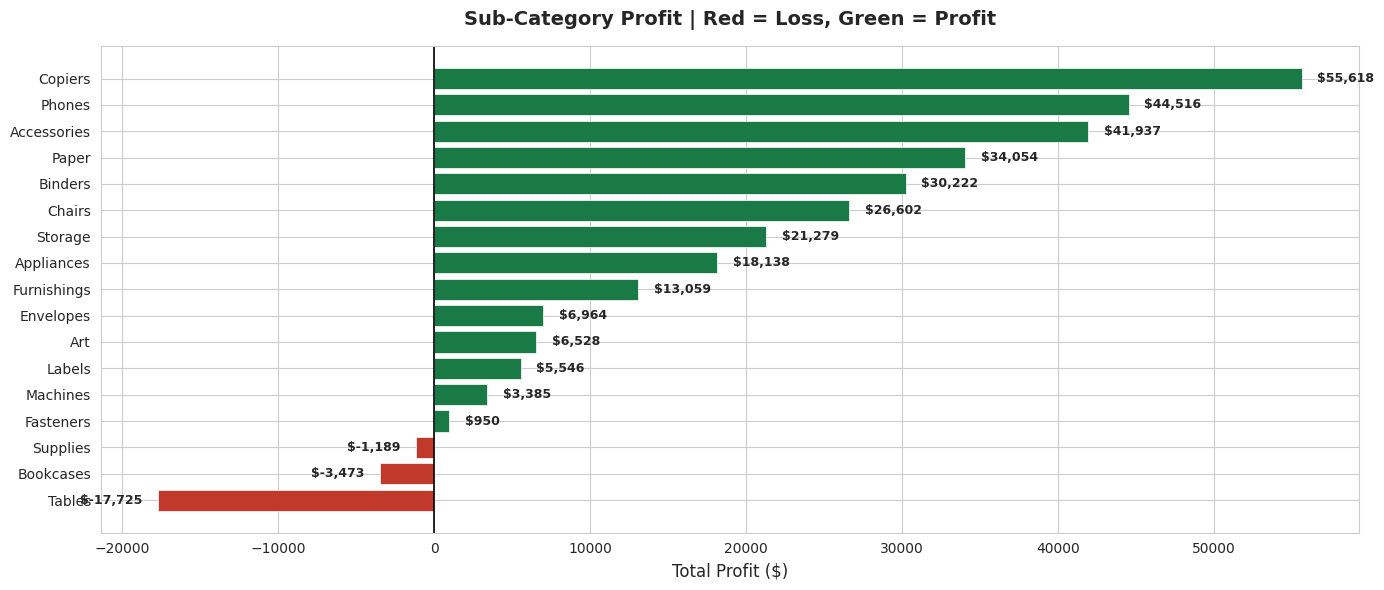

✅ Chart saved as chart1_subcategory_profit.png


In [ ]:
# ── CHART 1: Sub-Category Profit Bar Chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#C0392B' if x < 0 else '#1A7A45' for x in subcat['Total_Profit']]

bars = ax.barh(subcat.index, subcat['Total_Profit'], color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, subcat['Total_Profit']):
    ax.text(
        val + (1000 if val >= 0 else -1000),
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_title('Sub-Category Profit | Red = Loss, Green = Profit', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart1_subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart1_subcategory_profit.png')

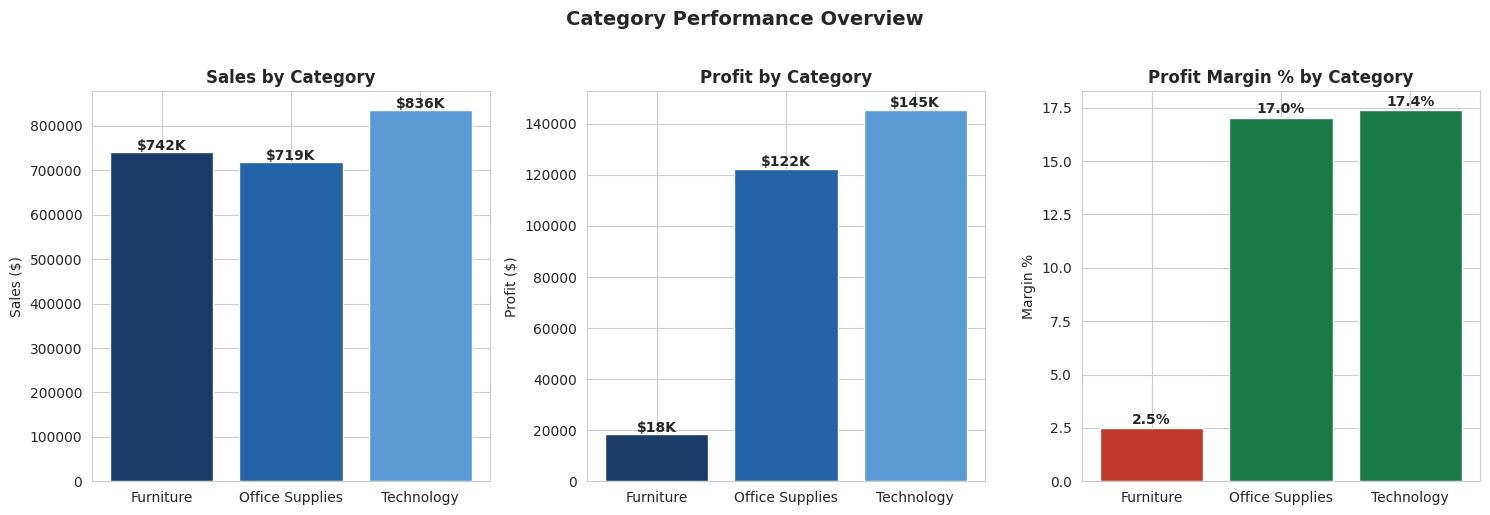

✅ Chart saved as chart2_category_overview.png


In [ ]:
# ── CHART 2: Category Comparison ─────────────────────────────────────────
cat = df.groupby('Category').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).round(2)
cat['Margin_Pct'] = (cat['Profit'] / cat['Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sales
axes[0].bar(cat.index, cat['Sales'], color=['#1A3C6B','#2563A8','#5B9BD5'])
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
for i, v in enumerate(cat['Sales']):
    axes[0].text(i, v + 5000, f'${v/1000:.0f}K', ha='center', fontweight='bold', fontsize=10)

# Profit
axes[1].bar(cat.index, cat['Profit'], color=['#1A3C6B','#2563A8','#5B9BD5'])
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
for i, v in enumerate(cat['Profit']):
    axes[1].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontweight='bold', fontsize=10)

# Margin
colors_m = ['#C0392B' if v < 10 else '#1A7A45' for v in cat['Margin_Pct']]
axes[2].bar(cat.index, cat['Margin_Pct'], color=colors_m)
axes[2].set_title('Profit Margin % by Category', fontweight='bold')
axes[2].set_ylabel('Margin %')
for i, v in enumerate(cat['Margin_Pct']):
    axes[2].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Category Performance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_category_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart2_category_overview.png')

## 📊 STEP 6 — Discount Impact Analysis
### (Answers: Are certain customer segments over-discounted?)

In [ ]:
# ── DISCOUNT BAND ANALYSIS ────────────────────────────────────────────────
disc = df.groupby('Discount_Band', observed=True).agg(
    Avg_Profit  = ('Profit',  'mean'),
    Order_Count = ('Profit',  'count'),
    Loss_Rate   = ('Profit',  lambda x: (x < 0).mean() * 100)
).round(2)

print('DISCOUNT BAND → PROFIT IMPACT')
print('=' * 55)
print(disc.to_string())
print('\n🔑 KEY INSIGHT:')
print('   Discount 0%    → Avg Profit: +$66.90  | Loss Rate: 0%')
print('   Discount 21-30% → Avg Profit: -$45.68  | Loss Rate: 91.6%')
print('   Discount 31%+  → Avg Profit: -$107.21 | Loss Rate: 97.8%')
print('\n⚠️  CONCLUSION: ANY discount above 20% almost guarantees a LOSS')

DISCOUNT BAND → PROFIT IMPACT
               Avg_Profit  Order_Count  Loss_Rate
Discount_Band                                    
0%                  66.90         4798       0.00
1-10%               96.06           94       4.26
11-20%              24.74         3709      13.99
21-30%             -45.83          226      91.59
31%+              -107.21         1166      97.77

🔑 KEY INSIGHT:
   Discount 0%    → Avg Profit: +$66.90  | Loss Rate: 0%
   Discount 21-30% → Avg Profit: -$45.68  | Loss Rate: 91.6%
   Discount 31%+  → Avg Profit: -$107.21 | Loss Rate: 97.8%

⚠️  CONCLUSION: ANY discount above 20% almost guarantees a LOSS


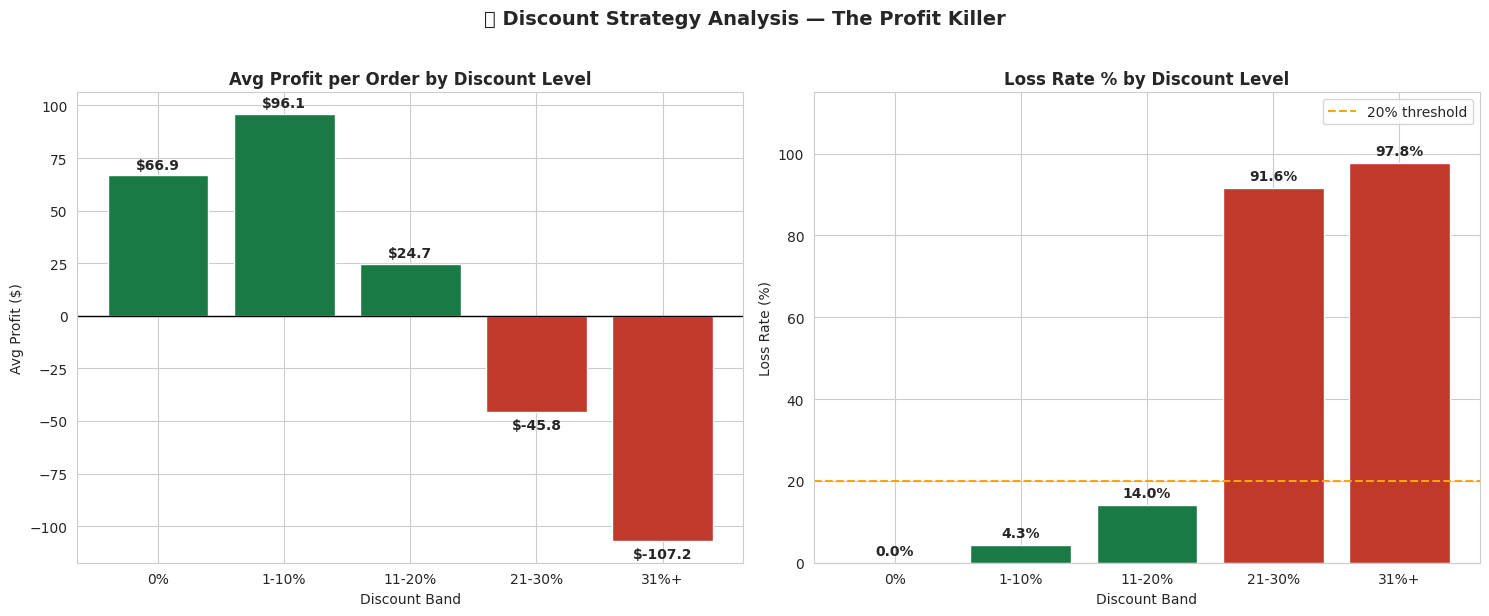

✅ Chart saved as chart3_discount_analysis.png


In [ ]:
# ── CHART 3: Discount vs Profit ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Avg Profit by Discount Band
disc_plot = disc.reset_index()
bar_colors = ['#1A7A45' if x >= 0 else '#C0392B' for x in disc_plot['Avg_Profit']]
bars = axes[0].bar(disc_plot['Discount_Band'], disc_plot['Avg_Profit'], color=bar_colors, edgecolor='white')
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('Avg Profit per Order by Discount Level', fontweight='bold')
axes[0].set_xlabel('Discount Band')
axes[0].set_ylabel('Avg Profit ($)')
for bar, val in zip(bars, disc_plot['Avg_Profit']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + (3 if val >= 0 else -8),
                 f'${val:.1f}', ha='center', fontweight='bold', fontsize=10)

# Right: Loss Rate by Discount Band
loss_colors = ['#1A7A45' if x < 20 else '#C0392B' for x in disc_plot['Loss_Rate']]
bars2 = axes[1].bar(disc_plot['Discount_Band'], disc_plot['Loss_Rate'], color=loss_colors, edgecolor='white')
axes[1].axhline(y=20, color='orange', linewidth=1.5, linestyle='--', label='20% threshold')
axes[1].set_title('Loss Rate % by Discount Level', fontweight='bold')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Loss Rate (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()
for bar, val in zip(bars2, disc_plot['Loss_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 2, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('💡 Discount Strategy Analysis — The Profit Killer', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart3_discount_analysis.png')

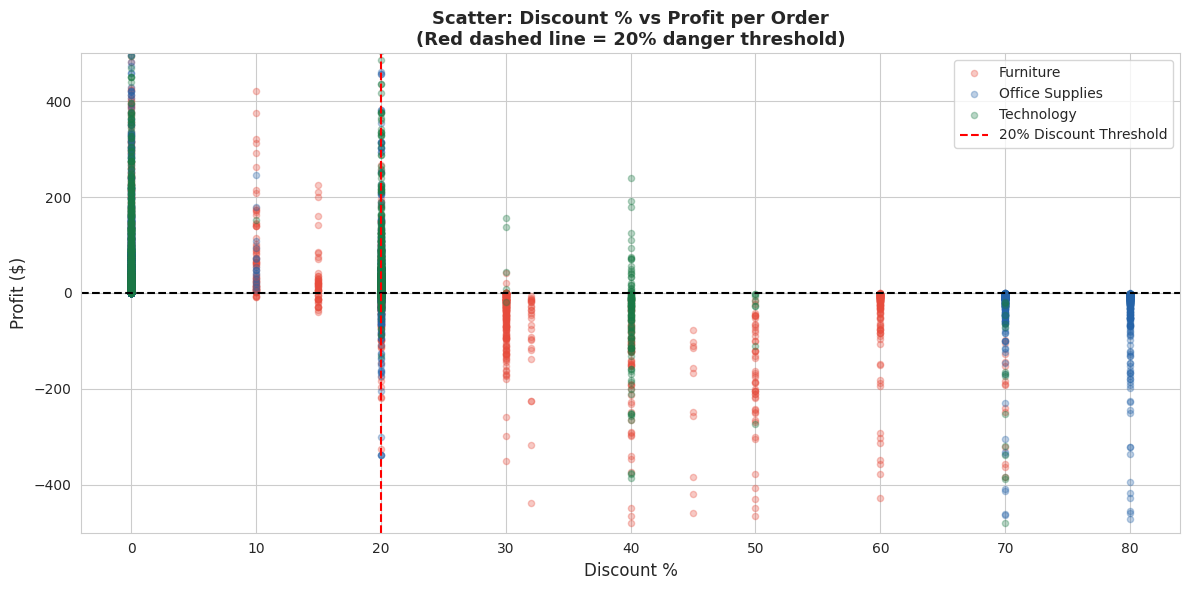

✅ Chart saved as chart4_discount_scatter.png


In [ ]:
# ── CHART 4: Scatter — Discount vs Profit per order ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

categories = df['Category'].unique()
cat_colors = {'Furniture': '#E74C3C', 'Office Supplies': '#2563A8', 'Technology': '#1A7A45'}

for cat_name in categories:
    subset = df[df['Category'] == cat_name]
    ax.scatter(
        subset['Discount'] * 100,
        subset['Profit'],
        alpha=0.3, s=20,
        color=cat_colors[cat_name],
        label=cat_name
    )

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(x=20, color='red', linewidth=1.5, linestyle='--', label='20% Discount Threshold')
ax.set_xlabel('Discount %', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Scatter: Discount % vs Profit per Order\n(Red dashed line = 20% danger threshold)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-500, 500)

plt.tight_layout()
plt.savefig('chart4_discount_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart4_discount_scatter.png')

## 📊 STEP 7 — Regional Analysis
### (Answers: Which region needs operational restructuring?)

In [ ]:
# ── REGIONAL ANALYSIS ────────────────────────────────────────────────────
region = df.groupby('Region').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Avg_Discount  = ('Discount', 'mean'),
    Order_Count   = ('Order ID', 'count')
).round(2)
region['Margin_Pct'] = (region['Total_Profit'] / region['Total_Sales'] * 100).round(2)
region['Avg_Discount_Pct'] = (region['Avg_Discount'] * 100).round(1)
region = region.sort_values('Margin_Pct', ascending=False)

print('REGIONAL PERFORMANCE')
print('=' * 70)
print(region[['Total_Sales','Total_Profit','Margin_Pct','Avg_Discount_Pct']].to_string())
print('\n🔑 KEY INSIGHT:')
print('   Central has 24% avg discount → only 7.92% margin')
print('   West has 11% avg discount    → 14.94% margin')
print('   Central needs discount policy restructuring IMMEDIATELY')

REGIONAL PERFORMANCE
         Total_Sales  Total_Profit  Margin_Pct  Avg_Discount_Pct
Region                                                          
West       725457.82     108418.45       14.94              11.0
East       678499.87      91534.84       13.49              15.0
South      391721.90      46749.43       11.93              15.0
Central    501239.89      39706.36        7.92              24.0

🔑 KEY INSIGHT:
   Central has 24% avg discount → only 7.92% margin
   West has 11% avg discount    → 14.94% margin
   Central needs discount policy restructuring IMMEDIATELY


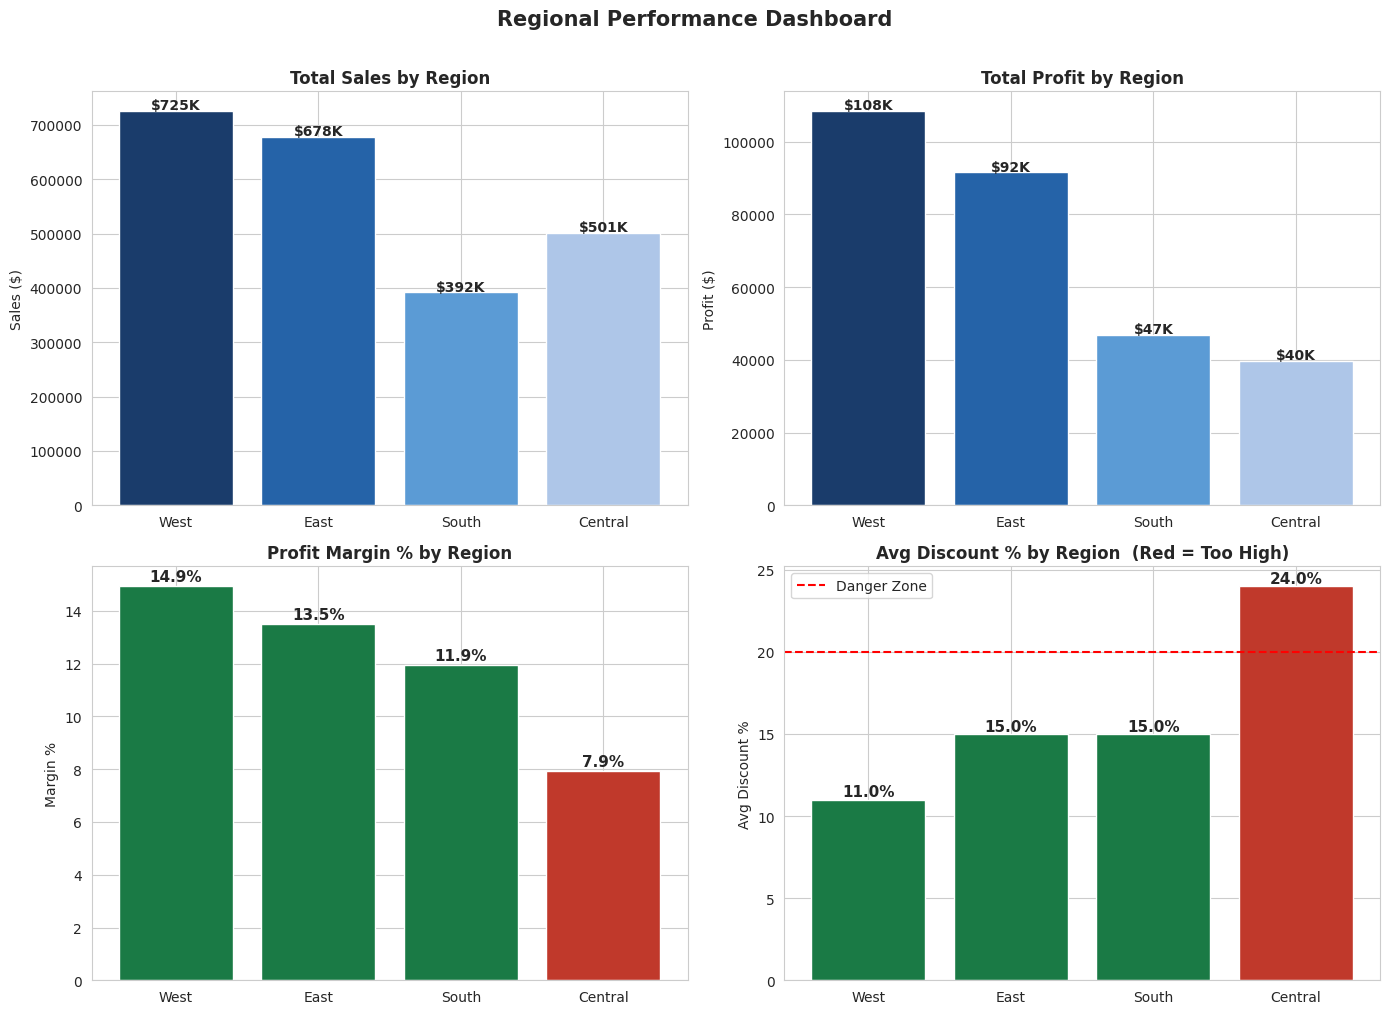

✅ Chart saved as chart5_regional_analysis.png


In [ ]:
# ── CHART 5: Region — Sales, Profit, Discount, Margin ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
region_reset = region.reset_index()
region_colors = ['#1A3C6B','#2563A8','#5B9BD5','#AEC6E8']

# Sales
axes[0,0].bar(region_reset['Region'], region_reset['Total_Sales'], color=region_colors)
axes[0,0].set_title('Total Sales by Region', fontweight='bold')
axes[0,0].set_ylabel('Sales ($)')
for i, v in enumerate(region_reset['Total_Sales']):
    axes[0,0].text(i, v+3000, f'${v/1000:.0f}K', ha='center', fontweight='bold', fontsize=10)

# Profit
axes[0,1].bar(region_reset['Region'], region_reset['Total_Profit'], color=region_colors)
axes[0,1].set_title('Total Profit by Region', fontweight='bold')
axes[0,1].set_ylabel('Profit ($)')
for i, v in enumerate(region_reset['Total_Profit']):
    axes[0,1].text(i, v+500, f'${v/1000:.0f}K', ha='center', fontweight='bold', fontsize=10)

# Margin %
m_colors = ['#C0392B' if v < 10 else '#1A7A45' for v in region_reset['Margin_Pct']]
axes[1,0].bar(region_reset['Region'], region_reset['Margin_Pct'], color=m_colors)
axes[1,0].set_title('Profit Margin % by Region', fontweight='bold')
axes[1,0].set_ylabel('Margin %')
for i, v in enumerate(region_reset['Margin_Pct']):
    axes[1,0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Avg Discount
d_colors = ['#C0392B' if v > 15 else '#1A7A45' for v in region_reset['Avg_Discount_Pct']]
axes[1,1].bar(region_reset['Region'], region_reset['Avg_Discount_Pct'], color=d_colors)
axes[1,1].set_title('Avg Discount % by Region  (Red = Too High)', fontweight='bold')
axes[1,1].set_ylabel('Avg Discount %')
axes[1,1].axhline(y=20, color='red', linewidth=1.5, linestyle='--', label='Danger Zone')
axes[1,1].legend()
for i, v in enumerate(region_reset['Avg_Discount_Pct']):
    axes[1,1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Regional Performance Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart5_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart5_regional_analysis.png')

In [ ]:
# ── STATE LEVEL — Loss States & Expansion Targets ────────────────────────
state = df.groupby('State').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum')
).round(2)
state['Margin_Pct'] = (state['Total_Profit'] / state['Total_Sales'] * 100).round(2)

print('TOP 5 LOSS STATES (Immediately address):')
print(state.sort_values('Total_Profit').head(5).to_string())

print('\nTOP 5 EXPANSION TARGETS (High margin, low sales):')
expansion = state[(state['Margin_Pct'] > 25) & (state['Total_Sales'] < 100000)]
print(expansion.sort_values('Margin_Pct', ascending=False).head(5).to_string())

TOP 5 LOSS STATES (Immediately address):
                Total_Sales  Total_Profit  Margin_Pct
State                                                
Texas             170188.05     -25729.36      -15.12
Ohio               77976.76     -16959.32      -21.75
Pennsylvania      116511.91     -15559.96      -13.35
Illinois           80166.10     -12607.89      -15.73
North Carolina     55603.16      -7490.91      -13.47

TOP 5 EXPANSION TARGETS (High margin, low sales):
                      Total_Sales  Total_Profit  Margin_Pct
State                                                      
District of Columbia      2865.02       1059.59       36.98
Delaware                 27451.07       9977.37       36.35
Minnesota                29863.15      10823.19       36.24
Maine                     1270.53        454.49       35.77
Arkansas                 11678.13       4008.69       34.33


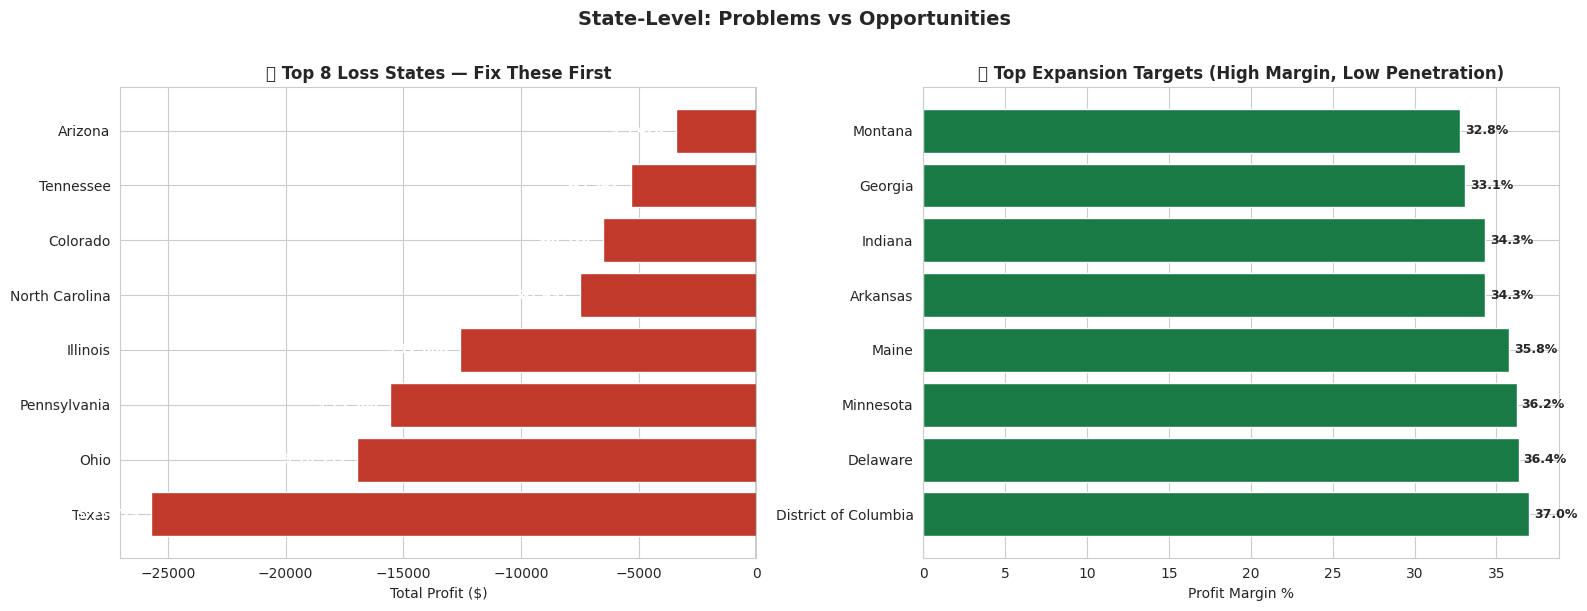

✅ Chart saved as chart6_state_analysis.png


In [ ]:
# ── CHART 6: Loss States vs Expansion States ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss states
loss_states = state.sort_values('Total_Profit').head(8).reset_index()
axes[0].barh(loss_states['State'], loss_states['Total_Profit'], color='#C0392B', edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('🔴 Top 8 Loss States — Fix These First', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
for i, v in enumerate(loss_states['Total_Profit']):
    axes[0].text(v - 500, i, f'${v:,.0f}', va='center', ha='right', fontsize=9, fontweight='bold', color='white')

# Expansion targets
exp_states = state[(state['Margin_Pct']>25) & (state['Total_Sales']<100000)].sort_values('Margin_Pct', ascending=False).head(8).reset_index()
axes[1].barh(exp_states['State'], exp_states['Margin_Pct'], color='#1A7A45', edgecolor='white')
axes[1].set_title('✅ Top Expansion Targets (High Margin, Low Penetration)', fontweight='bold')
axes[1].set_xlabel('Profit Margin %')
for i, v in enumerate(exp_states['Margin_Pct']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('State-Level: Problems vs Opportunities', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart6_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart6_state_analysis.png')

## 📊 STEP 8 — Shipping Analysis
### (Answers: Does faster shipping improve profit?)

In [ ]:
# ── SHIPPING ANALYSIS ─────────────────────────────────────────────────────
ship = df.groupby('Ship Mode').agg(
    Total_Profit    = ('Profit',        'sum'),
    Avg_Profit      = ('Profit',        'mean'),
    Avg_Delivery    = ('Delivery_Days', 'mean'),
    Order_Count     = ('Order ID',      'count'),
    Total_Sales     = ('Sales',         'sum')
).round(2)
ship['Margin_Pct']   = (ship['Total_Profit'] / ship['Total_Sales'] * 100).round(2)
ship['Volume_Share'] = (ship['Order_Count'] / ship['Order_Count'].sum() * 100).round(1)

print('SHIPPING MODE PERFORMANCE')
print('=' * 70)
print(ship[['Avg_Delivery','Margin_Pct','Order_Count','Volume_Share']].to_string())
print('\n🔑 KEY INSIGHT:')
print('   Standard Class = 59.7% of all orders but slowest (5 days) + lowest margin')
print('   First Class    = 13.9% margin, delivers in 2.2 days — underused')
print('   Shipping mode has MINOR impact on profit (1.8% diff) but BIG impact on delivery speed')

SHIPPING MODE PERFORMANCE
                Avg_Delivery  Margin_Pct  Order_Count  Volume_Share
Ship Mode                                                          
First Class             2.18       13.93         1538          15.4
Same Day                0.04       12.38          543           5.4
Second Class            3.24       12.51         1945          19.5
Standard Class          5.01       12.08         5967          59.7

🔑 KEY INSIGHT:
   Standard Class = 59.7% of all orders but slowest (5 days) + lowest margin
   First Class    = 13.9% margin, delivers in 2.2 days — underused
   Shipping mode has MINOR impact on profit (1.8% diff) but BIG impact on delivery speed


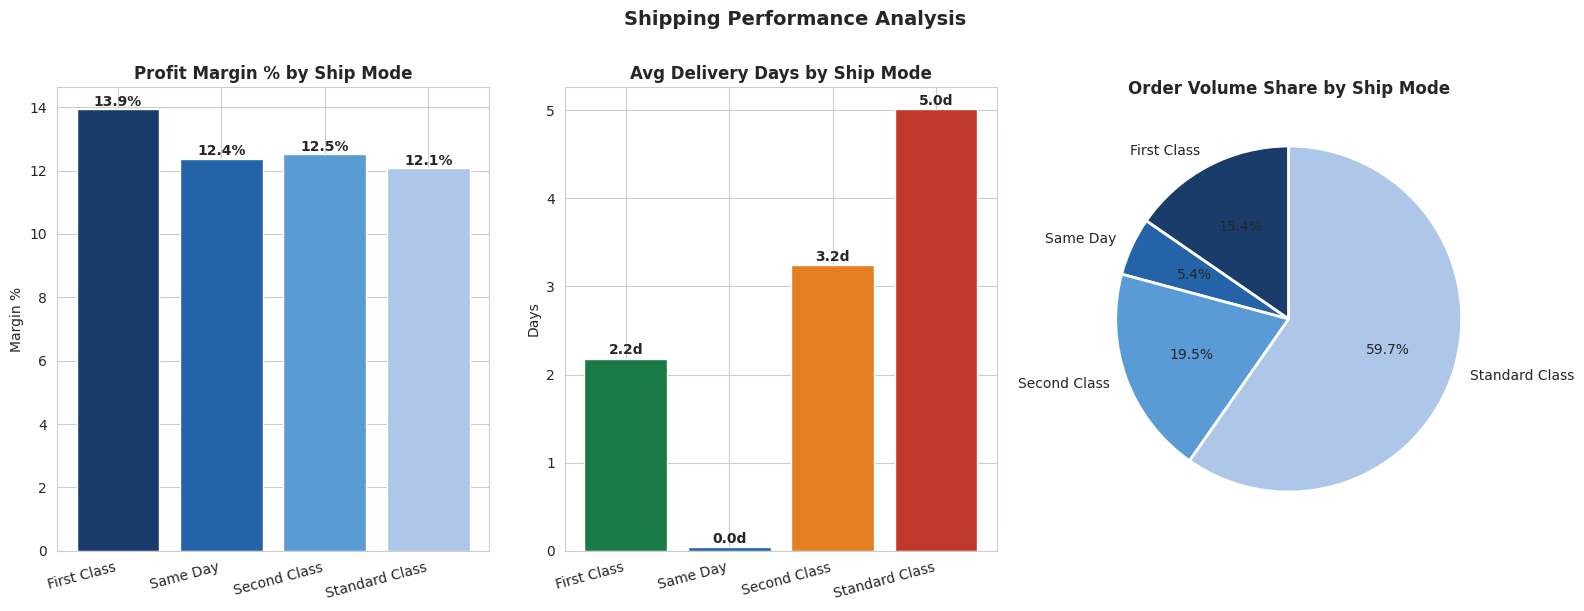

✅ Chart saved as chart7_shipping_analysis.png


In [ ]:
# ── CHART 7: Shipping Mode Analysis ──────────────────────────────────────
ship_reset = ship.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
ship_colors = ['#1A3C6B','#2563A8','#5B9BD5','#AEC6E8']

# Margin
axes[0].bar(ship_reset['Ship Mode'], ship_reset['Margin_Pct'], color=ship_colors)
axes[0].set_title('Profit Margin % by Ship Mode', fontweight='bold')
axes[0].set_ylabel('Margin %')
axes[0].set_xticklabels(ship_reset['Ship Mode'], rotation=15, ha='right')
for i, v in enumerate(ship_reset['Margin_Pct']):
    axes[0].text(i, v+0.1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Delivery Days
axes[1].bar(ship_reset['Ship Mode'], ship_reset['Avg_Delivery'], color=['#1A7A45','#2563A8','#E67E22','#C0392B'])
axes[1].set_title('Avg Delivery Days by Ship Mode', fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].set_xticklabels(ship_reset['Ship Mode'], rotation=15, ha='right')
for i, v in enumerate(ship_reset['Avg_Delivery']):
    axes[1].text(i, v+0.05, f'{v:.1f}d', ha='center', fontweight='bold', fontsize=10)

# Volume share pie
axes[2].pie(ship_reset['Order_Count'], labels=ship_reset['Ship Mode'],
            autopct='%1.1f%%', colors=ship_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Order Volume Share by Ship Mode', fontweight='bold')

plt.suptitle('Shipping Performance Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart7_shipping_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart7_shipping_analysis.png')

## 📊 STEP 9 — Year-over-Year Trend Analysis

In [ ]:
# ── TREND ANALYSIS ────────────────────────────────────────────────────────
yearly = df.groupby('Year').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).round(2)
yearly['Margin_Pct'] = (yearly['Profit'] / yearly['Sales'] * 100).round(2)

print('YEAR-OVER-YEAR TREND')
print(yearly.to_string())
print('\n🔑 KEY INSIGHT:')
print('   Sales grew from $484K (2014) to $733K (2017) — 51% growth')
print('   Profit grew from $49K to $93K — healthy trend')

YEAR-OVER-YEAR TREND
          Sales    Profit  Margin_Pct
Year                                 
2014  483966.13  49556.03       10.24
2015  470532.51  61618.60       13.10
2016  609205.60  81795.17       13.43
2017  733215.26  93439.27       12.74

🔑 KEY INSIGHT:
   Sales grew from $484K (2014) to $733K (2017) — 51% growth
   Profit grew from $49K to $93K — healthy trend


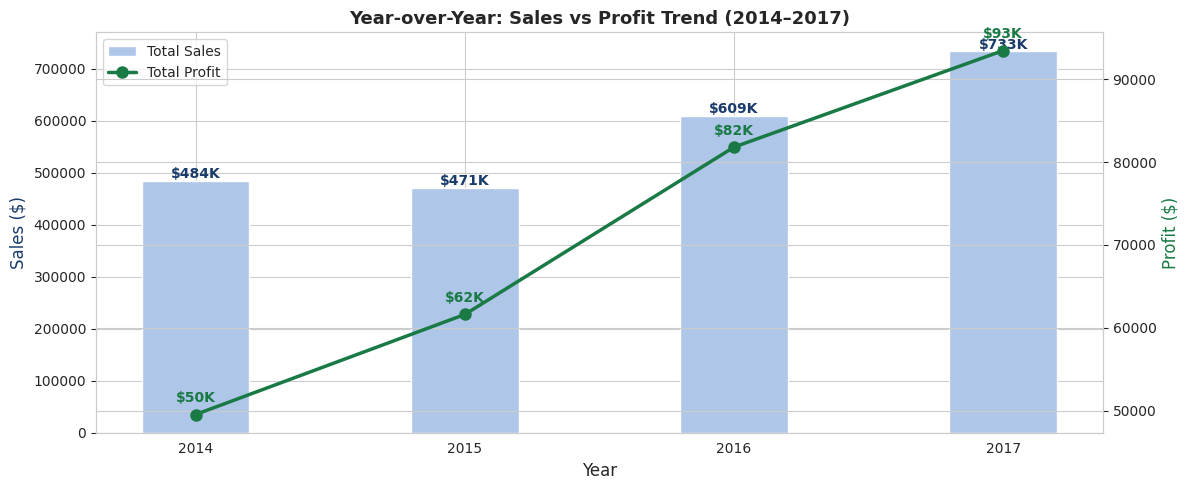

✅ Chart saved as chart8_yoy_trend.png


In [ ]:
# ── CHART 8: YoY Trend ────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

yearly_reset = yearly.reset_index()

ax1.bar(yearly_reset['Year'].astype(str), yearly_reset['Sales'],
        color='#AEC6E8', label='Total Sales', width=0.4, align='center')
ax1.set_ylabel('Sales ($)', color='#1A3C6B', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(yearly_reset['Year'].astype(str), yearly_reset['Profit'],
         color='#1A7A45', marker='o', linewidth=2.5, markersize=8, label='Total Profit')
ax2.set_ylabel('Profit ($)', color='#1A7A45', fontsize=12)

for i, (s, p) in enumerate(zip(yearly_reset['Sales'], yearly_reset['Profit'])):
    ax1.text(i, s + 5000, f'${s/1000:.0f}K', ha='center', fontsize=10, fontweight='bold', color='#1A3C6B')
    ax2.text(i, p + 1500, f'${p/1000:.0f}K', ha='center', fontsize=10, fontweight='bold', color='#1A7A45')

ax1.set_title('Year-over-Year: Sales vs Profit Trend (2014–2017)', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart8_yoy_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as chart8_yoy_trend.png')

## 📊 STEP 10 — Segment Analysis

In [ ]:
# ── SEGMENT ANALYSIS ──────────────────────────────────────────────────────
seg = df.groupby('Segment').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Avg_Discount  = ('Discount', 'mean'),
    Order_Count   = ('Order ID', 'count')
).round(2)
seg['Margin_Pct']        = (seg['Total_Profit'] / seg['Total_Sales'] * 100).round(2)
seg['Avg_Discount_Pct']  = (seg['Avg_Discount'] * 100).round(1)

print('SEGMENT PERFORMANCE')
print(seg[['Total_Sales','Total_Profit','Margin_Pct','Avg_Discount_Pct']].to_string())
print('\n🔑 KEY INSIGHT:')
print('   Home Office has best margin (14%) despite least revenue')
print('   Consumer = highest revenue but lowest margin (11.5%)')
print('   All 3 segments have similar discount rates — not a segment issue')

SEGMENT PERFORMANCE
             Total_Sales  Total_Profit  Margin_Pct  Avg_Discount_Pct
Segment                                                             
Consumer      1161401.34     134119.21       11.55              16.0
Corporate      706146.37      91979.13       13.03              16.0
Home Office    429371.78      60310.74       14.05              15.0

🔑 KEY INSIGHT:
   Home Office has best margin (14%) despite least revenue
   Consumer = highest revenue but lowest margin (11.5%)
   All 3 segments have similar discount rates — not a segment issue


## 📊 STEP 11 — Top Loss Products (Discontinue List)

In [ ]:
# ── TOP LOSS PRODUCTS ─────────────────────────────────────────────────────
prod = df.groupby('Product Name').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum'),
    Order_Count  = ('Order ID','count')
).round(2)
prod['Margin_Pct'] = (prod['Total_Profit'] / prod['Total_Sales'] * 100).round(2)

print('🔴 TOP 10 PRODUCTS TO DISCONTINUE (Highest Losses):')
print(prod.sort_values('Total_Profit').head(10)[['Total_Sales','Total_Profit','Margin_Pct']].to_string())

print('\n✅ TOP 10 STAR PRODUCTS (Highest Profits):')
print(prod.sort_values('Total_Profit', ascending=False).head(10)[['Total_Sales','Total_Profit','Margin_Pct']].to_string())

🔴 TOP 10 PRODUCTS TO DISCONTINUE (Highest Losses):
                                                                   Total_Sales  Total_Profit  Margin_Pct
Product Name                                                                                            
Cubify CubeX 3D Printer Double Head Print                             11099.96      -8879.97      -80.00
Lexmark MX611dhe Monochrome Laser Printer                             16829.90      -4589.97      -27.27
Cubify CubeX 3D Printer Triple Head Print                              7999.98      -3839.99      -48.00
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases               9917.64      -2876.12      -29.00
Bush Advantage Collection Racetrack Conference Table                   9544.72      -1934.40      -20.27
GBC DocuBind P400 Electric Binding System                             17965.07      -1878.17      -10.45
Cisco TelePresence System EX90 Videoconferencing Unit                 22638.48      -1811.08       -8.00
Mart

## 💾 STEP 12 — Export Final Clean File for Power BI

In [ ]:
# ── EXPORT ────────────────────────────────────────────────────────────────
# This creates the final file to load into Power BI
# ──────────────────────────────────────────────────────────────────────────

df.to_csv('superstore_final_powerbi.csv', index=False)

print('✅ File exported: superstore_final_powerbi.csv')
print(f'   Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Columns: {df.columns.tolist()}')
print('\n📥 HOW TO DOWNLOAD FROM COLAB:')
print('   1. Click the Folder icon on the left sidebar')
print('   2. Find superstore_final_powerbi.csv')
print('   3. Right-click → Download')
print('   4. Load this file into Power BI Desktop')

✅ File exported: superstore_final_powerbi.csv
   Shape  : 9993 rows × 28 columns
   Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin_Pct', 'Delivery_Days', 'Is_Loss', 'Year', 'Quarter', 'Month', 'Discount_Band']

📥 HOW TO DOWNLOAD FROM COLAB:
   1. Click the Folder icon on the left sidebar
   2. Find superstore_final_powerbi.csv
   3. Right-click → Download
   4. Load this file into Power BI Desktop


In [ ]:
# ── FINAL SUMMARY PRINTOUT ────────────────────────────────────────────────
print('=' * 60)
print('       PHASE 2 COMPLETE — SUMMARY OF FINDINGS')
print('=' * 60)
print()
print('🔴 CRITICAL ISSUES FOUND:')
print('   1. Tables sub-cat: $207K sales → -$17,725 LOSS (-8.6%)')
print('   2. Bookcases:      $115K sales → -$3,473 LOSS (-3.0%)')
print('   3. Discount >20%:  91.6% orders LOSE money')
print('   4. Central region: 24% avg discount, only 7.9% margin')
print('   5. Texas alone:    -$25,729 total loss')
print()
print('✅ OPPORTUNITIES FOUND:')
print('   1. Copiers:    $149K sales → +$55,618 profit (37.2%)')
print('   2. Paper:      44.4% margin — best in portfolio')
print('   3. Delaware:   36.4% margin — top expansion target')
print('   4. Minnesota:  36.2% margin — second expansion target')
print()
print('📊 CHARTS GENERATED (all saved as .png files):')
charts = [
    'chart1_subcategory_profit.png',
    'chart2_category_overview.png',
    'chart3_discount_analysis.png',
    'chart4_discount_scatter.png',
    'chart5_regional_analysis.png',
    'chart6_state_analysis.png',
    'chart7_shipping_analysis.png',
    'chart8_yoy_trend.png'
]
for c in charts:
    print(f'   ✔ {c}')
print()
print('📁 FILE TO LOAD IN POWER BI:')
print('   → superstore_final_powerbi.csv')
print('=' * 60)

       PHASE 2 COMPLETE — SUMMARY OF FINDINGS

🔴 CRITICAL ISSUES FOUND:
   1. Tables sub-cat: $207K sales → -$17,725 LOSS (-8.6%)
   2. Bookcases:      $115K sales → -$3,473 LOSS (-3.0%)
   3. Discount >20%:  91.6% orders LOSE money
   4. Central region: 24% avg discount, only 7.9% margin
   5. Texas alone:    -$25,729 total loss

✅ OPPORTUNITIES FOUND:
   1. Copiers:    $149K sales → +$55,618 profit (37.2%)
   2. Paper:      44.4% margin — best in portfolio
   3. Delaware:   36.4% margin — top expansion target
   4. Minnesota:  36.2% margin — second expansion target

📊 CHARTS GENERATED (all saved as .png files):
   ✔ chart1_subcategory_profit.png
   ✔ chart2_category_overview.png
   ✔ chart3_discount_analysis.png
   ✔ chart4_discount_scatter.png
   ✔ chart5_regional_analysis.png
   ✔ chart6_state_analysis.png
   ✔ chart7_shipping_analysis.png
   ✔ chart8_yoy_trend.png

📁 FILE TO LOAD IN POWER BI:
   → superstore_final_powerbi.csv
